# Importing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data = pd.read_table("/content/SMSSpamCollection.txt",
                    sep="\t",
                    header=None,
                    names=["label", "messages"])
data.head()

,label,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
data.isnull().sum()
#no null data

,0
label,0
messages,0


In [4]:
data.shape

(5572, 2)

In [5]:
data.describe()

,label,messages
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [6]:
data.info()
print(data['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     5572 non-null   object
 1   messages  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
label
ham     4825
spam     747
Name: count, dtype: int64


#Data Manipulation

#PLAN??
1. First lets see the common words in ham and spam
2. Then lets just keep these words so that uk we can make the model not go for extra calculations
3. Then lets make graphs so that we can understand the relations present in spam and ham
4. I would like to make a column tbh for the words that are for spam and ham (Text Preprocessing)


In [7]:
sp=len(data["label"][data.label=="spam"])
ha=len(data["label"][data.label=="ham"])
print("spam:",sp,"and","ham:",ha)

spam: 747 and ham: 4825


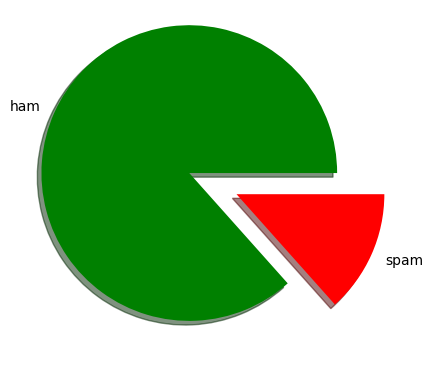

In [8]:
#pie chart
arr=[ha,sp]
labels=["ham","spam"]
plt.pie(arr,labels=labels, explode=[0.35,0.0],shadow=True,colors=["g","r"])
plt.show()

So now we need to change texts to numbers for comparison, We can use a  vectoriser

In [9]:
def text_preprocess(x):
    x = str(x).lower()
    x = x.replace(",000,000", "m").replace(",000", "k").replace("′", "'").replace("’", "'")\
                           .replace("won't", "will not").replace("cannot", "can not").replace("can't", "can not")\
                           .replace("n't", " not").replace("what's", "what is").replace("it's", "it is")\
                           .replace("'ve", " have").replace("i'm", "i am").replace("'re", " are")\
                           .replace("he's", "he is").replace("she's", "she is").replace("'s", " own")\
                           .replace("%", " percent ").replace("₹", " rupee ").replace("$", " dollar ")\
                           .replace("€", " euro ").replace("'ll", " will")
    return x

data["Preprocessed Text"] = data["messages"].apply(lambda x: text_preprocess(x))
#.apply(lambda x: ...): Iterates over each row (x) in that column.
data.head()

,label,messages,Preprocessed Text
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i do not think he goes to usf, he lives ar..."


In [16]:

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['label']=le.fit_transform(data['label'])
sp=len(data["label"][data.label== 1])
ha=len(data["label"][data.label==0])
print(sp,ha)


747 4825


# Training Model

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['Preprocessed Text'],
                                                    data['label'],
                                                    random_state=1)

print('Number of rows in the total set: {}'.format(data.shape[0]))
print('Number of rows in the training set: {}'.format(X_train.shape[0]))
print('Number of rows in the test set: {}'.format(X_test.shape[0]))

Number of rows in the total set: 5572
Number of rows in the training set: 4179
Number of rows in the test set: 1393


In [12]:
from sklearn.feature_extraction.text import CountVectorizer
# Instantiate the CountVectorizer method
count_vector = CountVectorizer()

# Fit the training data and then return the matrix
training_data = count_vector.fit_transform(X_train)

# Transform testing data and return the matrix. Note we are not fitting the testing data into the CountVectorizer()
testing_data = count_vector.transform(X_test)

In [13]:
from sklearn.naive_bayes import MultinomialNB
naive_bayes = MultinomialNB()
naive_bayes.fit(training_data, y_train)
predictions = naive_bayes.predict(testing_data)
predictions

# read more about Naive Bayes:- https://en.wikipedia.org/wiki/Naive_Bayes_classifier

array([0, 0, 0, ..., 0, 1, 0])

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print('Accuracy score: ', format(accuracy_score(y_test, predictions)))
print('Precision score: ', format(precision_score(y_test, predictions)))
print('Recall score: ', format(recall_score(y_test, predictions)))
print('F1 score: ', format(f1_score(y_test, predictions)))
#High accuracy

Accuracy score:  0.9877961234745154
Precision score:  0.9719101123595506
Recall score:  0.9351351351351351
F1 score:  0.953168044077135


# Testing

In [15]:
doc = pd.Series("This is the 2nd time we have tried 2 contact u...")
test = count_vector.transform(doc)
naive_bayes.predict(test)

array([0])